In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [ ]:
print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images :", X_test.shape)
print("Testing Labels :", y_test.shape)

Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 1)
Testing Images : (10000, 32, 32, 3)
Testing Labels : (10000, 1)


In [ ]:
class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

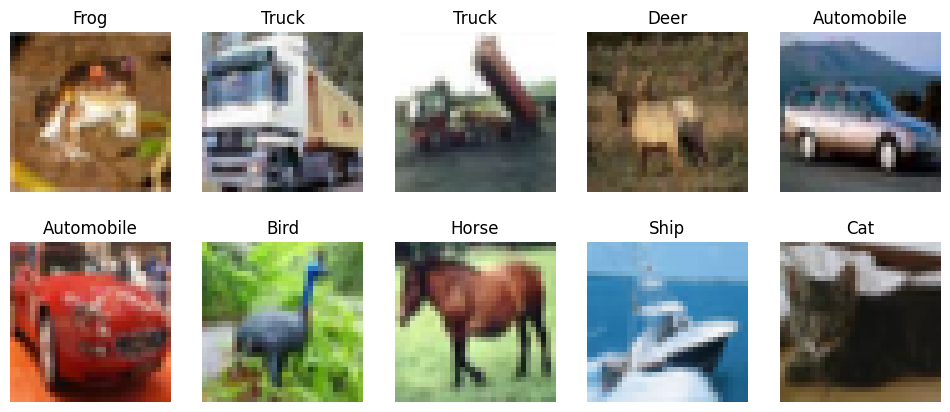

In [ ]:
plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

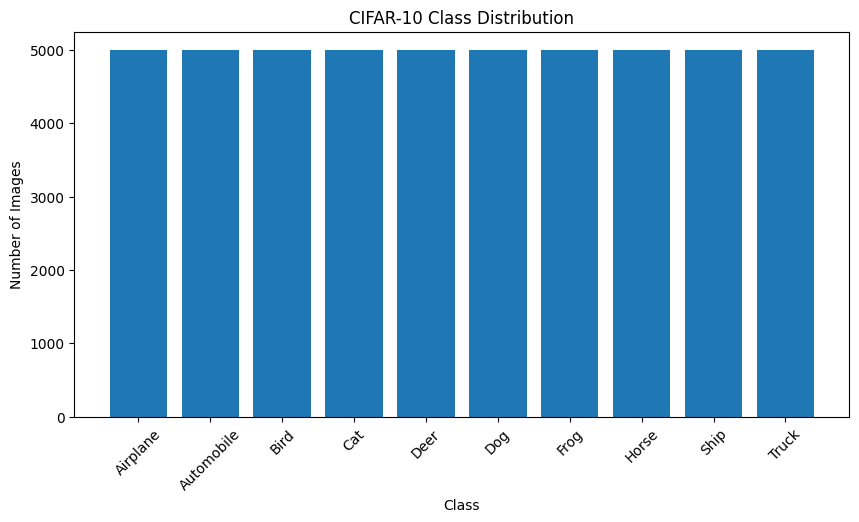

In [ ]:
labels = y_train.flatten()

counts = np.bincount(labels)

plt.figure(figsize=(10,5))
plt.bar(class_names, counts)

plt.xticks(rotation=45)

plt.xlabel("Class")

plt.ylabel("Number of Images")

plt.title("CIFAR-10 Class Distribution")

plt.show()

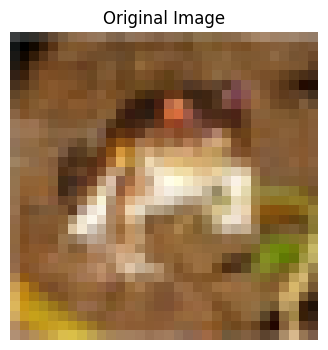

Original Image Shape : (1, 32, 32, 3)
3x3 Feature Map Shape : (1, 30, 30, 1)
5x5 Feature Map Shape : (1, 28, 28, 1)
7x7 Feature Map Shape : (1, 26, 26, 1)


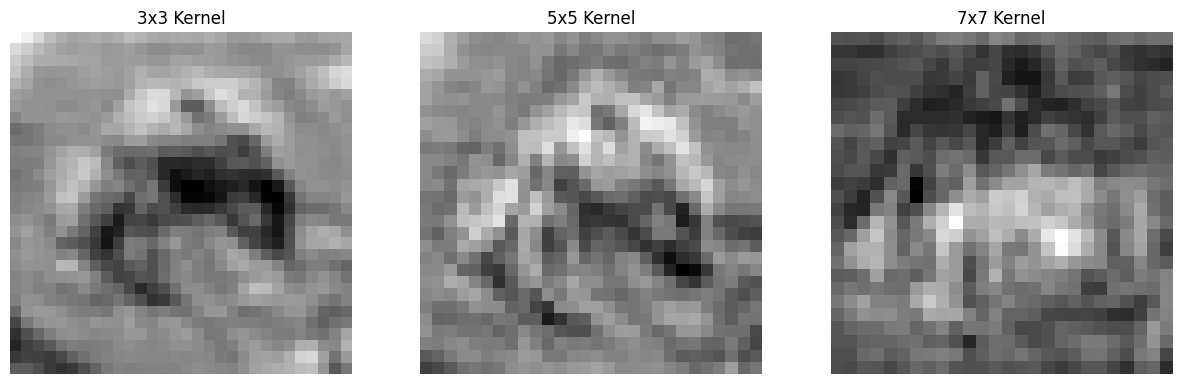

In [ ]:
# =====================================================
# TASK 2
# Implement Convolution Layer
# Compare Kernel Sizes (3x3, 5x5, 7x7)
# =====================================================

# Select one sample image from the training dataset
image = X_train[0]

# Normalize image and convert to float32
image = image.astype("float32") / 255.0

# Display Original Image
plt.figure(figsize=(4,4))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

# Add batch dimension
# Shape changes:
# (32,32,3) --> (1,32,32,3)

image = np.expand_dims(image, axis=0)

# Create convolution layers
conv3 = tf.keras.layers.Conv2D(
    filters=1,
    kernel_size=3,
    strides=1,
    padding='valid'
)

conv5 = tf.keras.layers.Conv2D(
    filters=1,
    kernel_size=5,
    strides=1,
    padding='valid'
)

conv7 = tf.keras.layers.Conv2D(
    filters=1,
    kernel_size=7,
    strides=1,
    padding='valid'
)

# Apply convolution
feature3 = conv3(image)
feature5 = conv5(image)
feature7 = conv7(image)

# Print output feature map sizes
print("Original Image Shape :", image.shape)
print("3x3 Feature Map Shape :", feature3.shape)
print("5x5 Feature Map Shape :", feature5.shape)
print("7x7 Feature Map Shape :", feature7.shape)

# Convert tensors to numpy arrays
feature3 = feature3.numpy()
feature5 = feature5.numpy()
feature7 = feature7.numpy()

# Display feature maps
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(feature3[0, :, :, 0], cmap="gray")
plt.title("3x3 Kernel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(feature5[0, :, :, 0], cmap="gray")
plt.title("5x5 Kernel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(feature7[0, :, :, 0], cmap="gray")
plt.title("7x7 Kernel")
plt.axis("off")

plt.show()

Input Shape : (1, 32, 32, 3)

Stride = 1, Padding = Valid
(1, 30, 30, 1)

Stride = 2, Padding = Valid
(1, 15, 15, 1)

Stride = 1, Padding = Same
(1, 32, 32, 1)

Stride = 2, Padding = Same
(1, 16, 16, 1)


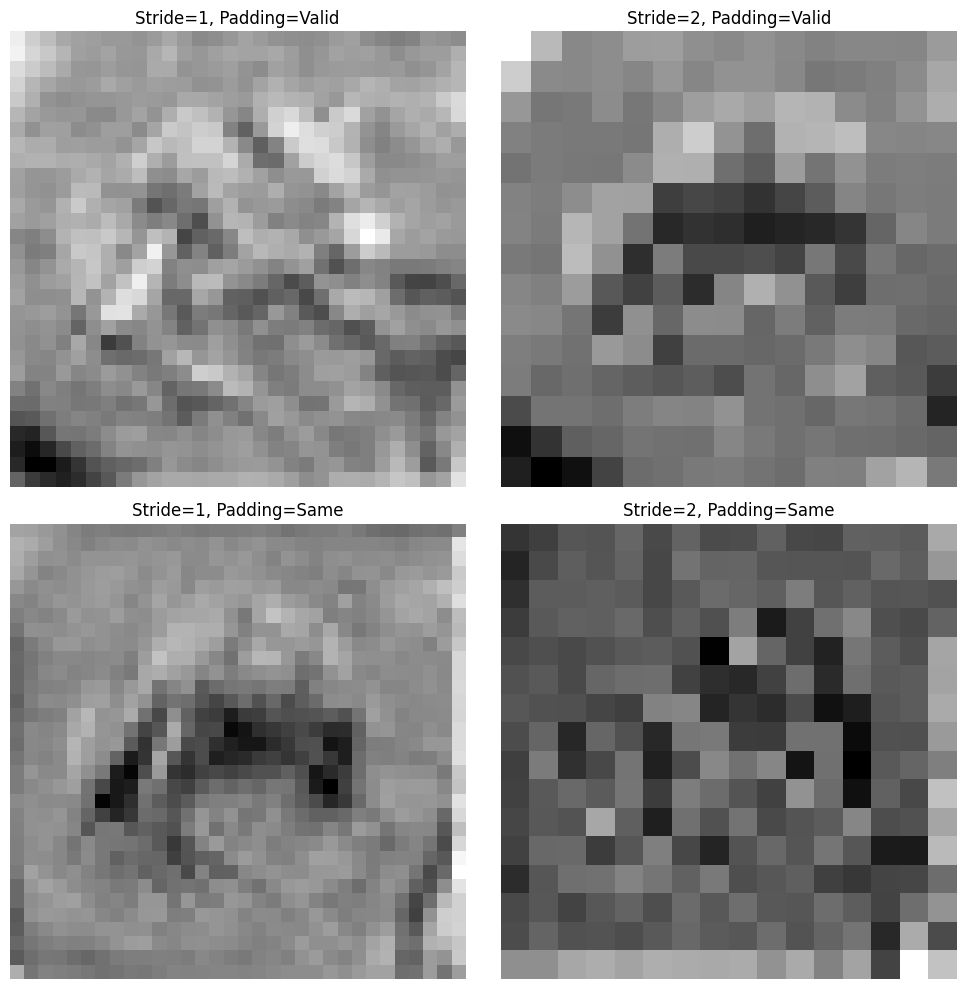

In [ ]:
# =====================================================
# TASK 3
# Compare Stride and Padding
# =====================================================

# -------------------------
# Stride = 1, Padding = Valid
# -------------------------
conv_stride1_valid = tf.keras.layers.Conv2D(
    filters=1,
    kernel_size=3,
    strides=1,
    padding='valid'
)

output_stride1_valid = conv_stride1_valid(image)

# -------------------------
# Stride = 2, Padding = Valid
# -------------------------
conv_stride2_valid = tf.keras.layers.Conv2D(
    filters=1,
    kernel_size=3,
    strides=2,
    padding='valid'
)

output_stride2_valid = conv_stride2_valid(image)

# -------------------------
# Stride = 1, Padding = Same
# -------------------------
conv_stride1_same = tf.keras.layers.Conv2D(
    filters=1,
    kernel_size=3,
    strides=1,
    padding='same'
)

output_stride1_same = conv_stride1_same(image)

# -------------------------
# Stride = 2, Padding = Same
# -------------------------
conv_stride2_same = tf.keras.layers.Conv2D(
    filters=1,
    kernel_size=3,
    strides=2,
    padding='same'
)

output_stride2_same = conv_stride2_same(image)

# -------------------------
# Print Output Shapes
# -------------------------
print("Input Shape :", image.shape)

print("\nStride = 1, Padding = Valid")
print(output_stride1_valid.shape)

print("\nStride = 2, Padding = Valid")
print(output_stride2_valid.shape)

print("\nStride = 1, Padding = Same")
print(output_stride1_same.shape)

print("\nStride = 2, Padding = Same")
print(output_stride2_same.shape)

# -------------------------
# Display Feature Maps
# -------------------------
fig, ax = plt.subplots(2,2, figsize=(10,10))

ax[0,0].imshow(output_stride1_valid[0,:,:,0], cmap='gray')
ax[0,0].set_title("Stride=1, Padding=Valid")
ax[0,0].axis("off")

ax[0,1].imshow(output_stride2_valid[0,:,:,0], cmap='gray')
ax[0,1].set_title("Stride=2, Padding=Valid")
ax[0,1].axis("off")

ax[1,0].imshow(output_stride1_same[0,:,:,0], cmap='gray')
ax[1,0].set_title("Stride=1, Padding=Same")
ax[1,0].axis("off")

ax[1,1].imshow(output_stride2_same[0,:,:,0], cmap='gray')
ax[1,1].set_title("Stride=2, Padding=Same")
ax[1,1].axis("off")

plt.tight_layout()
plt.show()

Feature Map Shape : (1, 32, 32, 8)


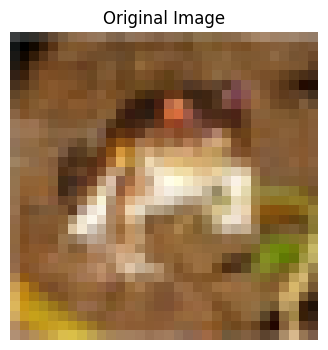

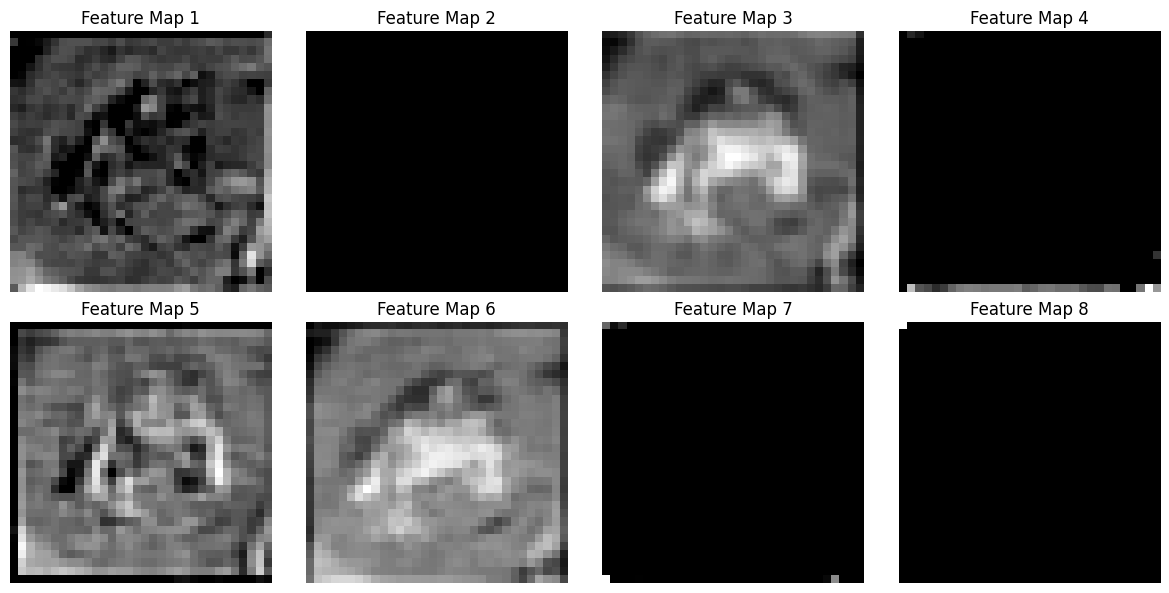

In [ ]:
# =====================================================
# TASK 4
# Visualize Feature Maps
# =====================================================

# Create convolution layer with 8 filters
conv_layer = tf.keras.layers.Conv2D(
    filters=8,
    kernel_size=3,
    strides=1,
    padding='same',
    activation='relu'
)

# Apply convolution
feature_maps = conv_layer(image)

print("Feature Map Shape :", feature_maps.shape)

# Convert tensor to NumPy
feature_maps = feature_maps.numpy()

# Display Original Image
plt.figure(figsize=(4,4))
plt.imshow(image[0])
plt.title("Original Image")
plt.axis("off")
plt.show()

# Display 8 Feature Maps
plt.figure(figsize=(12,6))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(feature_maps[0,:,:,i], cmap='gray')

    plt.title(f"Feature Map {i+1}")

    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
# =====================================================
# TASK 4
# Build CNN and Visualize Feature Maps
# =====================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D

# Build CNN Model
model = Sequential([
    Conv2D(
        filters=8,
        kernel_size=(3,3),
        activation='relu',
        padding='same',
        input_shape=(32,32,3)
    ),

    MaxPooling2D(pool_size=(2,2))
])

# Print Model Summary
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 8)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224 (896.00 B)

 Trainable params: 224 (896.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =====================================================
# TASK 6
# Build and Train CNN
# =====================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Normalize the dataset
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Build CNN Model
cnn = Sequential([

    # First Convolution Layer
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        padding='same',
        input_shape=(32,32,3)
    ),

    # First Pooling Layer
    MaxPooling2D(pool_size=(2,2)),

    # Second Convolution Layer
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),

    # Second Pooling Layer
    MaxPooling2D(pool_size=(2,2)),

    # Flatten Layer
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),

    # Output Layer
    Dense(10, activation='softmax')
])

# Display Model Summary
cnn.summary()

# Compile the Model
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the Model
history = cnn.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 73s 113ms/step - accuracy: 0.2063 - loss: 2.1497 - val_accuracy: 0.2874 - val_loss: 2.0130
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 113ms/step - accuracy: 0.3037 - loss: 1.9547 - val_accuracy: 0.3218 - val_loss: 1.9047
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 113ms/step - accuracy: 0.3447 - loss: 1.8253 - val_accuracy: 0.3476 - val_loss: 1.8119
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 112ms/step - accuracy: 0.3748 - loss: 1.7300 - val_accuracy: 0.3826 - val_loss: 1.7086
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 87s 120ms/step - accuracy: 0.4003 - loss: 1.6693 - val_accuracy: 0.4022 - val_loss: 1.6615
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 73s 116ms/step - accuracy: 0.4130 - loss: 1.6294 - val_accuracy: 0.4108 - val_loss: 1.6279
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 120ms/step - accuracy: 0.4255 - loss: 1.5997 - val_accuracy: 0.4237 - val_loss: 1.6066
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 113ms/step - accuracy: 0.4354 - loss: 1